# S6 Transfer Function Equivalence
3C6 Section 6: equivalence of transfer function expressions

## imports and definitions

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
matplotlib.rcParams.update({'font.size': 12,'font.family':'serif'})
import os
from IPython.display import HTML, display
from ipywidgets import Output, widgets, Layout

In [2]:
%matplotlib widget

## Setup properties

In [3]:
# setup parameters
L = 1
P = 1
m = 1
c = np.sqrt(P/m)
x = 0.6*L
a = 0.2*L

w1 = np.pi*c/L
N = 20

# Create axes
w = np.linspace(0.01,(N+1)*w1,1000)

# Direct approach
if x<a:
    G1 = c/(w*P) * np.sin(w*(L-a)/c) * np.sin(w*x/c) / np.sin(w*L/c)
else:
    G1 = c/(w*P) * np.sin(w*a/c) * np.sin(w*(L-x)/c) / np.sin(w*L/c)

Button(button_style='primary', description='Add another mode', layout=Layout(width='95%'), style=ButtonStyle()…

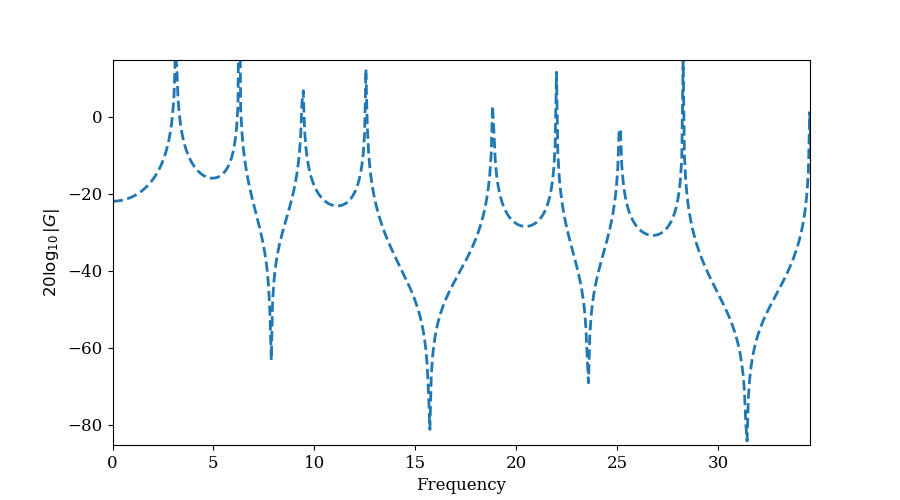

In [4]:
plt.figure(figsize=(9,5),dpi=100)
yscale = np.percentile(20*np.log10(np.abs(G1)),[1,99]) # Get axis scaling to look ok for undamped case
plt.ylim(yscale)
plt.xlabel('Frequency')
plt.ylabel('$20 \log_{10}|G|$')
plt.xlim([0,11*w1])
plt.ylim([yscale[0]-10,yscale[1]+10])

p1 = plt.plot([],[],linestyle='--',linewidth=2,label='direct')
p1[0].set_data(w,20*np.log10(np.abs(G1)))
p2 = plt.plot([],[],linewidth=2,label='modal sum')

G2 = 0
n=0
button = widgets.Button(description="Add another mode",layout=Layout(width='95%'))
button.button_style = 'primary'
display(button)

def next_plot(b):
    global G2,n
    n += 1
    G2 += 2/(m*L) * np.sin(n*np.pi*a/L) * np.sin(n*np.pi*x/L) / ((n*w1)**2 - w**2)
    
    p2[0].set_data(w,20*np.log10(np.abs(G2)))
    
    plt.title("number of modes = {}".format(n))
    plt.legend(loc='lower left')
    if n >= 20:
        button.layout.visibility = 'hidden'
    plt.draw()
    

button.on_click(next_plot)